### **Improtación y libreriras**

In [1]:

#pip install ucimlrepo

In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import sklearn as sk
import seaborn as sns
import sys
#from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from imblearn.over_sampling import SMOTE
from google.colab import files




In [3]:

uploaded = files.upload()


Saving phishing.csv to phishing.csv


In [4]:
#utilizando la API de UCIREPO
#phishing_websites = fetch_ucirepo(id=327)
#features = phishing_websites.data.features
#resultado = phishing_websites.data.targets

#Utilizando Kaggel
dataset = pd.read_csv('/content/phishing.csv')
dataset = dataset.drop(columns=['Index'])



### **Lectura de los datos**

--------------------Distribucion de sitios web malicioso y oficiales---------------

1: oficial y legitimo
-1: phishing
class
 1    6157
-1    4897
Name: count, dtype: int64


/tmp/ipykernel_21726/1322721811.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=resultado, palette='magma')


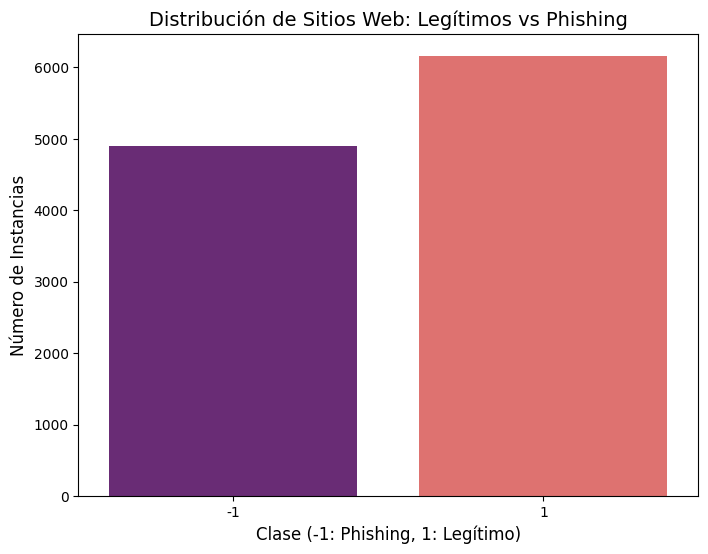

------------------------------valores faltantes------------------

0
UsingIP                0
LongURL                0
ShortURL               0
Symbol@                0
Redirecting//          0
PrefixSuffix-          0
SubDomains             0
HTTPS                  0
DomainRegLen           0
Favicon                0
NonStdPort             0
HTTPSDomainURL         0
RequestURL             0
AnchorURL              0
LinksInScriptTags      0
ServerFormHandler      0
InfoEmail              0
AbnormalURL            0
WebsiteForwarding      0
StatusBarCust          0
DisableRightClick      0
UsingPopupWindow       0
IframeRedirection      0
AgeofDomain            0
DNSRecording           0
WebsiteTraffic         0
PageRank               0
GoogleIndex            0
LinksPointingToPage    0
StatsReport            0
dtype: int64
----------------------info general----------------------

<bound method DataFrame.info of        UsingIP  LongURL  ShortURL  Symbol@  Redirecting//  PrefixSuffix-  \
0 

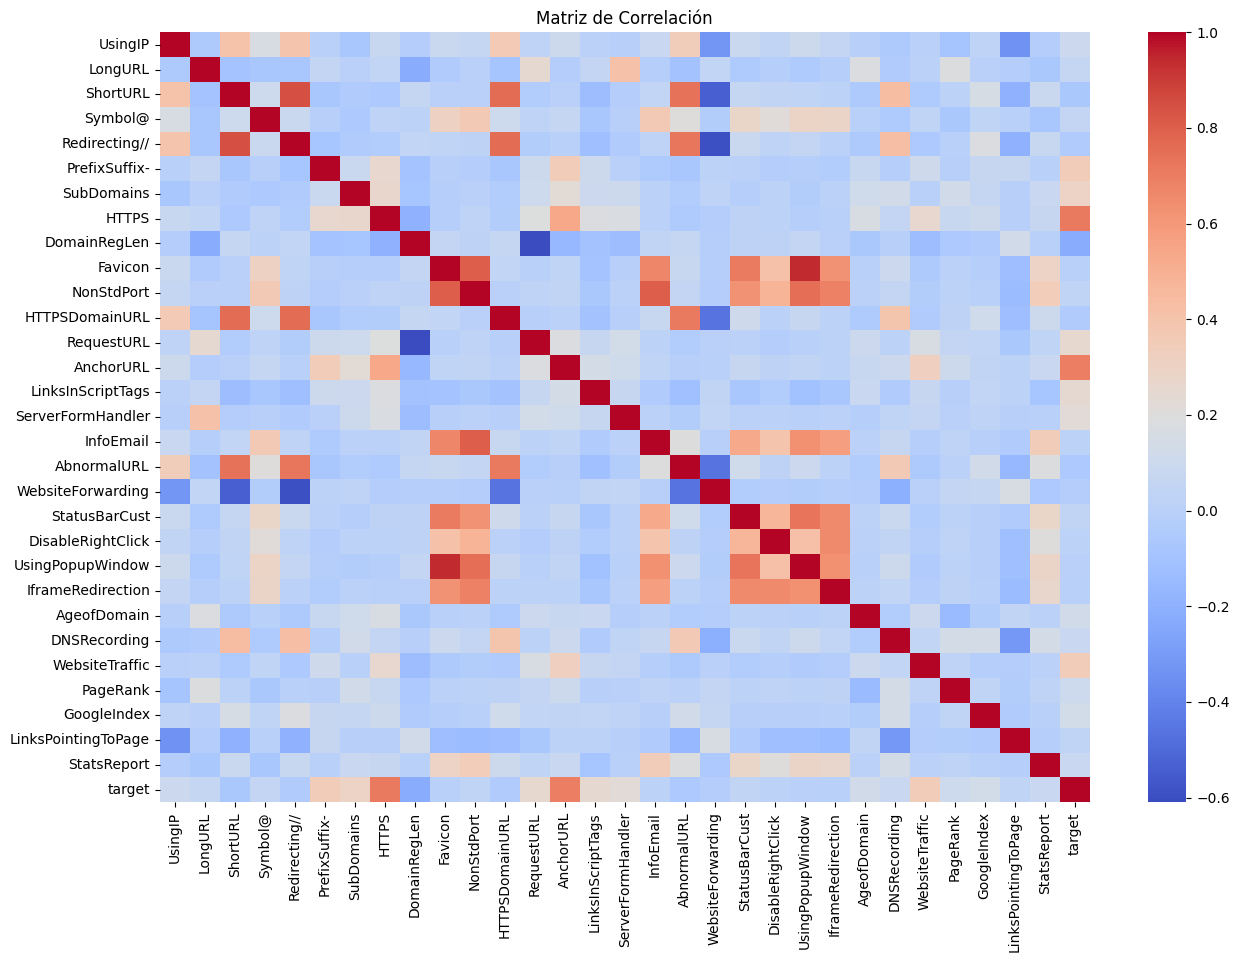

In [5]:

features = dataset.drop(columns=['class'])
resultado = dataset['class']

print("--------------------Distribucion de sitios web malicioso y oficiales---------------\n")
print("1: oficial y legitimo")
print("-1: phishing")
print(resultado.value_counts())


plt.figure(figsize=(8, 6))
sns.countplot(x=resultado, palette='magma')
plt.title('Distribución de Sitios Web: Legítimos vs Phishing', fontsize=14)
plt.xlabel('Clase (-1: Phishing, 1: Legítimo)', fontsize=12)
plt.ylabel('Número de Instancias', fontsize=12)
plt.show()


print("------------------------------valores faltantes------------------\n")
print(resultado.isnull().sum())
print(features.isnull().sum())

print("----------------------info general----------------------\n")
print(dataset.info)

print("-----------------------------Matriz de correlación-----------------\n")
plt.figure(figsize=(15, 10))
sns.heatmap(features.assign(target=resultado).corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()



### **Preprocesamiento**

/tmp/ipykernel_21726/2481946002.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=resultado_SMOTE, palette='magma')


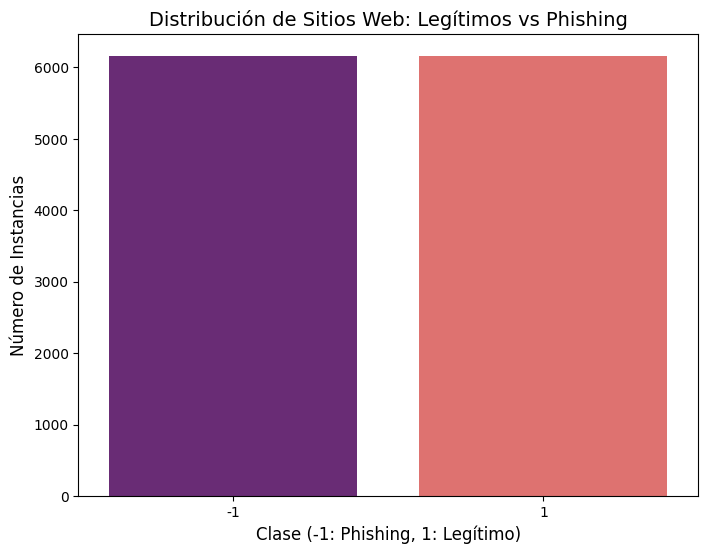

HTTPS             12314
AnchorURL         12314
PrefixSuffix-     12314
WebsiteTraffic    12314
SubDomains        12314
RequestURL        12314
dtype: int64
12314
-------Dataset balanceado------


In [6]:
features_Elegidas = dataset[['HTTPS','AnchorURL','PrefixSuffix-','WebsiteTraffic','SubDomains','RequestURL']]
resultados = dataset['class']

features_SMOTE, resultado_SMOTE = SMOTE(sampling_strategy='minority', random_state=42).fit_resample(features_Elegidas, resultados)
features_Balance, resultado_Balance = sk.utils.shuffle(features_SMOTE, resultado_SMOTE, random_state=42)

plt.figure(figsize=(8, 6))
sns.countplot(x=resultado_SMOTE, palette='magma')
plt.title('Distribución de Sitios Web: Legítimos vs Phishing', fontsize=14)
plt.xlabel('Clase (-1: Phishing, 1: Legítimo)', fontsize=12)
plt.ylabel('Número de Instancias', fontsize=12)
plt.show()

print(features_Balance.count())
print(resultado_Balance.count())

resultados_transform = resultado_Balance.replace(-1,0)


if(resultados_transform.value_counts()[0] == resultados_transform.value_counts()[1]):
    print("-------Dataset balanceado------")
else:
    print("----------Dataset desbalanceado--------")

features_entrenamiento, features_prueba, resultado_entrenamiento, resultado_prueba = train_test_split(features_Balance, resultados_transform, test_size=0.2, random_state=42)

features_prueba, feature_validation, resultado_prueba, resultado_validation = train_test_split(features_prueba, resultado_prueba, test_size=0.2, random_state=42)

In [7]:
features_entrenamiento_final = StandardScaler().fit_transform(features_entrenamiento)

features_prueba_Final = StandardScaler().fit_transform(features_prueba)

print("--------------------features entrenamiento------------------\n")
print(features_entrenamiento_final)
print("--------------------features prueba------------------\n")
print(features_prueba_Final)
print("--------------------resultados entrnamiento------------------\n")
print(resultado_entrenamiento)
print("--------------------resultados prueba------------------\n")
print(resultado_prueba)


--------------------features entrenamiento------------------

[[-0.2066121   0.18377731 -0.36783178 -1.51360779 -0.04969222 -1.17450781]
 [-1.29619232 -1.20990265 -0.36783178  0.89306646 -1.27963705  0.85142048]
 [ 0.88296811  0.18377731 -0.36783178  0.89306646 -1.27963705  0.85142048]
 ...
 [-1.29619232 -1.20990265 -0.36783178 -1.51360779  1.18025261 -1.17450781]
 [ 0.88296811  0.18377731 -0.36783178 -0.31027066 -1.27963705  0.85142048]
 [-1.29619232  0.18377731 -0.36783178  0.89306646 -0.04969222  0.85142048]]
--------------------features prueba------------------

[[-1.22209461 -1.18231154 -0.35998216 -0.30214275 -1.26189877 -1.12908228]
 [ 0.92078602  1.59876755 -0.35998216  0.91507855 -0.03123512 -1.12908228]
 [ 0.92078602  0.208228   -0.35998216 -1.51936405  1.19942853 -1.12908228]
 ...
 [ 0.92078602  1.59876755  2.77791543 -1.51936405  1.19942853  0.88567505]
 [-0.1506543  -1.18231154 -0.35998216 -0.30214275 -0.03123512 -1.12908228]
 [-1.22209461  0.208228   -0.35998216 -0.302142

# **Modelo de redes neuronales usando arbol de desiciones**


In [8]:
model = DecisionTreeClassifier(max_depth=6, random_state=42)

In [9]:
model.fit(features_entrenamiento, resultado_entrenamiento,)

DecisionTreeClassifier(max_depth=6, random_state=42)

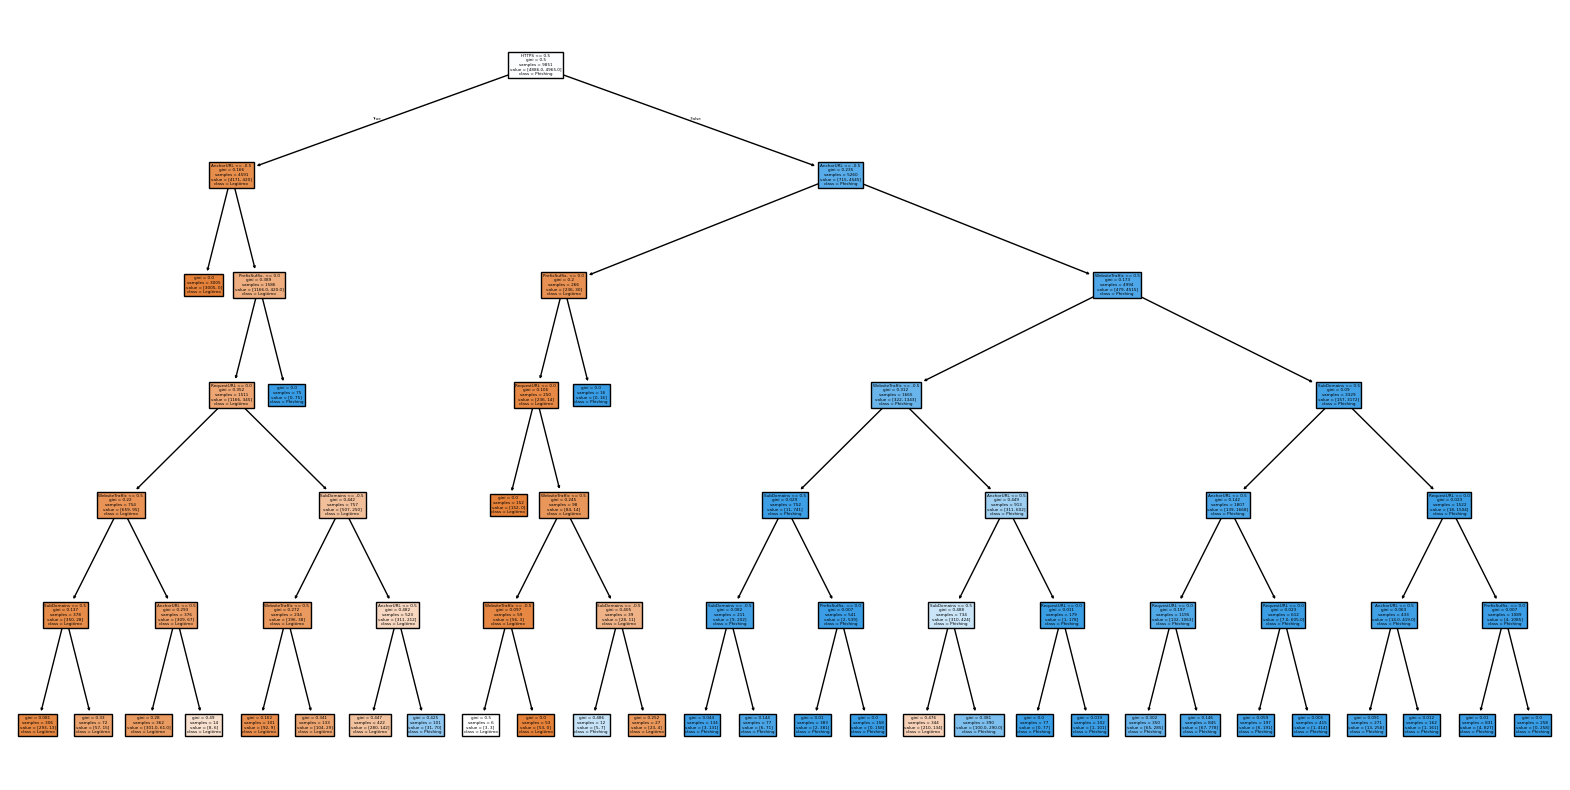

In [10]:
plt.figure(figsize=(20,10))
plot_tree(model,feature_names=features_entrenamiento.columns,class_names=["Legitimo", "Phishing"],filled=True)
plt.show()

In [11]:
modelopredict = model.predict(features_prueba)

In [12]:
predicciones = np.array(modelopredict).flatten()
reales = np.array(resultado_prueba).flatten()

TP = 0
TN = 0
FP = 0
FN = 0

for i in range(len(reales)):
    if predicciones[i] == 1:
        if reales[i] == 1:
            TP = TP + 1
        else:
            FP = FP + 1
    else:
        if reales[i] == 0:
            TN = TN + 1
        else:
            FN = FN + 1

print("--- MATRIZ DE CONFUSIÓN---")
print(f"{'                '} | 'Real Phishing (0)' | 'Real Legítimo (1)'")
print("------------------------------------------------------------------------" )
print(f"'Pred Phishing(0)' | {TN} | {FN}")
print(f"'Pred Legítimo(1)' | {FP} | {TP}")
print("------------------------------------------------------------------------" )

if (TN + FP) > 0:
    recall_phishing = TN / (TN + FP)
    precision_phishing = TN / (TN + FN)
    if (precision_phishing + recall_phishing) > 0:
        F1Score = 2 * (precision_phishing * recall_phishing) / (precision_phishing + recall_phishing)
    else:
        F1Score = 0
    print(f"Recall de Phishing: {recall_phishing:.2%}")
    print(f"Precisión de Phishing {precision_phishing:.2%}")
    print(f"F1-Score de Phishing: {F1Score:.2%}")
else:
    print("No hay casos de Phishing en el set de prueba.")

--- MATRIZ DE CONFUSIÓN---
                 | 'Real Phishing (0)' | 'Real Legítimo (1)'
------------------------------------------------------------------------
'Pred Phishing(0)' | 954 | 90
'Pred Legítimo(1)' | 58 | 868
------------------------------------------------------------------------
Recall de Phishing: 94.27%
Precisión de Phishing 91.38%
F1-Score de Phishing: 92.80%
